# Viscosity Prediction Pipeline
Step-by-step analysis of `height_normalized.csv` using `RheologyPipeline`.

## Step 1 — Imports & load raw data

In [43]:
import sys, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Make sure the repo root is importable
REPO = Path(r"C:\Users\mrast\OneDrive\Documents\GitHub\Automated_Viscometry")
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from rheology_pipeline_core import RheologyPipeline, fit_drag_profile, ConeGeometry

# ── Load data ────────────────────────────────────────────────────────────────
CSV_PATH = REPO / "results" / "Auto-runs" / "height_normalized.csv"
df_raw = pd.read_csv(CSV_PATH)

print(f"Loaded: {CSV_PATH.name}")
print(f"Shape : {df_raw.shape}  ({df_raw.shape[0]} height rows, {df_raw.shape[1]-1} silicone samples)")
print()
display(df_raw.head())


Loaded: height_normalized.csv
Shape : (31, 24)  (31 height rows, 23 silicone samples)



,Height,1kcp_1.073_torque_%_rpm_47,2kcp_3.345_torque_%_rpm_15,4kcp_6.603_torque_%_rpm_8,5kcp_5.861_torque_%_rpm_9,8kcp_8.946_torque_%_rpm_5.6,10kcp_9.152_torque_%_rpm_5.5,12.5kcp_14.576_torque_%_rpm_3.5,15kcp_19.036_torque_%_rpm_2.6,20kcp_24.396_torque_%_rpm_2.1,...,45kcp_40.820_torque_%_rpm_1.2,50kcp_79.653_torque_%_rpm_0.6,55kcp_48.553_torque_%_rpm_1,60kcp_68.953_torque_%_rpm_0.8,70kcp_87.046_torque_%_rpm_0.5,75kcp_70.730_torque_%_rpm_0.7,80kcp_103.800_torque_%_rpm_0.5,90kcp_102.466_torque_%_rpm_0.5,95kcp_93.400_torque_%_rpm_0.5,100kcp_124.033_torque_%_rpm_0.4
0,0.00,1.535177,4.614667,8.442500,7.435556,11.625595,13.023030,19.227619,25.797436,33.980952,...,55.733333,99.016667,63.850000,92.987500,132.886667,89.766667,145.420000,145.266667,131.260000,160.866667
1,0.02,1.393901,4.194222,7.837083,7.008889,11.008333,11.944848,17.844762,23.305128,31.006349,...,51.155556,95.627778,58.886667,83.925000,118.313333,84.333333,137.986667,129.853333,118.540000,141.775000
2,0.04,1.318369,3.909333,7.429583,6.699630,10.432738,11.436364,16.795238,21.892308,28.998413,...,48.202778,91.094444,55.776667,79.425000,111.860000,79.871429,123.766667,123.913333,112.666667,135.391667
3,0.06,1.256525,3.735556,7.098750,6.295926,9.945238,10.996970,16.000000,21.362821,27.473016,...,46.125000,86.394444,53.166667,75.745833,107.046667,76.242857,118.293333,118.226667,106.686667,129.208333
4,0.08,1.196525,3.556222,6.786250,6.011481,9.462500,10.546667,15.248571,20.125641,26.217460,...,43.866667,82.805556,50.883333,72.300000,102.306667,72.785714,112.553333,113.440000,101.566667,124.558333


In [44]:
# ── Google style constants ────────────────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# Set Arial font globally
mpl.rcParams['font.family'] = 'Arial'

GOOGLE_COLORS = ["#4285F4", "#EA4335", "#FBBC05", "#34A853", "#FF6D00", "#46BDC6"]

# Continuous colormap: Google Blue → Yellow → Red
GOOGLE_CMAP = LinearSegmentedColormap.from_list(
    "google", [GOOGLE_COLORS[0], GOOGLE_COLORS[2], GOOGLE_COLORS[1]]
)

BORDER = 1.5
FS_LABEL = 20    # axis label font size
FS_TICK  = 14    # tick label font size
FS_LEGEND = 14   # legend font size

def _gs(ax):
    """Apply Google style to an Axes: no grid, thick border, tick size."""
    ax.grid(False)
    ax.tick_params(labelsize=FS_TICK)
    for spine in ax.spines.values():
        spine.set_linewidth(BORDER)

def _cb(mappable, ax, label):
    """Add a styled colorbar."""
    cb = plt.colorbar(mappable, ax=ax)
    cb.set_label(label, fontsize=FS_LEGEND)
    cb.ax.tick_params(labelsize=FS_TICK - 2)
    cb.outline.set_linewidth(BORDER)
    return cb

print("Google style palette & Arial font loaded.")


Google style palette & Arial font loaded.


## Step 1b — Load full_run_260428.csv & plot Drag vs Spindle Height

Loaded : full_run_260428.csv
Rows   : 474
Samples: 18


,Cell_Label,Z_Height_mm,RPM,Rotational_Drag
0,1kcP_bluesil,-65.50,45.0,0.523556
1,1kcP_bluesil,-65.52,45.0,0.550444
2,1kcP_bluesil,-65.54,45.0,0.566222
3,1kcP_bluesil,-65.56,45.0,0.584222


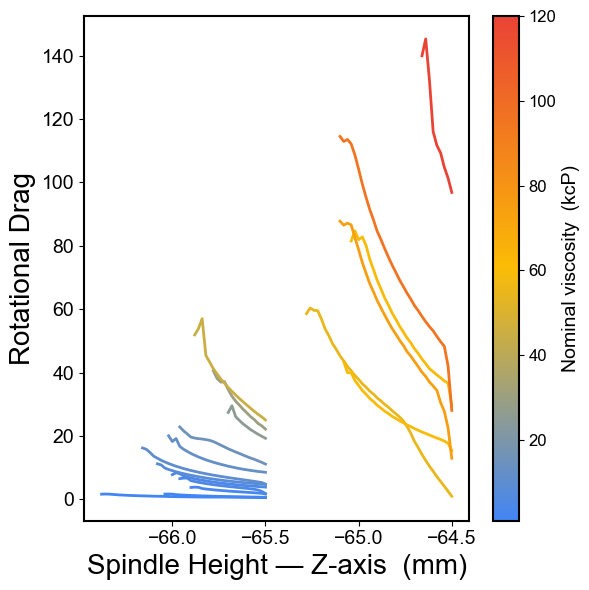

In [45]:
import re as _re

# ── Load ──────────────────────────────────────────────────────────────────────
FULL_RUN_PATH = REPO / "results" / "Auto-runs" / "full_run_260428.csv"
df_run = pd.read_csv(
    FULL_RUN_PATH,
    usecols=["Cell_Label", "Z_Height_mm", "RPM", "Rotational_Drag"]
)
df_run["Z_Height_mm"]    = pd.to_numeric(df_run["Z_Height_mm"],    errors="coerce")
df_run["Rotational_Drag"] = pd.to_numeric(df_run["Rotational_Drag"], errors="coerce")
df_run = df_run.dropna(subset=["Z_Height_mm", "Rotational_Drag"])

# Parse nominal viscosity (kcP) from label prefix: "12.5kcP_sdl5" → 12.5
def _kcp(label):
    m = _re.match(r"^([\d.]+)kcP", str(label))
    return float(m.group(1)) if m else np.nan

labels_ordered = sorted(df_run["Cell_Label"].unique(), key=_kcp)
kcp_vals       = [_kcp(l) for l in labels_ordered]

print(f"Loaded : {FULL_RUN_PATH.name}")
print(f"Rows   : {len(df_run):,}")
print(f"Samples: {len(labels_ordered)}")
display(df_run.head(4))

# ── Plot: Drag vs Z-Height, one curve per sample ──────────────────────────────
norm_run = plt.Normalize(vmin=min(kcp_vals), vmax=max(kcp_vals))
sm_run   = plt.cm.ScalarMappable(cmap=GOOGLE_CMAP, norm=norm_run)
sm_run.set_array([])

fig, ax = plt.subplots(figsize=(6, 6))

for label in labels_ordered:
    kcp = _kcp(label)
    sub = df_run[df_run["Cell_Label"] == label].sort_values("Z_Height_mm")
    ax.plot(
        sub["Z_Height_mm"],
        sub["Rotational_Drag"],
        color=GOOGLE_CMAP(norm_run(kcp)),
        lw=2.0,
    )

ax.set_xlabel("Spindle Height — Z-axis  (mm)", fontsize=FS_LABEL)
ax.set_ylabel("Rotational Drag", fontsize=FS_LABEL)
_cb(sm_run, ax, "Nominal viscosity  (kcP)")
_gs(ax)
plt.tight_layout()
plt.show()


## Step 2 — Parse column metadata & visualize raw drag profiles

Parsed 23 silicone samples


,col,nom_kcp,mu_cP,rpm
0,1kcp_1.073_torque_%_rpm_47,1.0,1073.0,47.0
1,2kcp_3.345_torque_%_rpm_15,2.0,3345.0,15.0
2,5kcp_5.861_torque_%_rpm_9,5.0,5861.0,9.0
3,4kcp_6.603_torque_%_rpm_8,4.0,6603.0,8.0
4,8kcp_8.946_torque_%_rpm_5.6,8.0,8946.0,5.6
5,10kcp_9.152_torque_%_rpm_5.5,10.0,9152.0,5.5
6,12.5kcp_14.576_torque_%_rpm_3.5,12.5,14576.0,3.5
7,15kcp_19.036_torque_%_rpm_2.6,15.0,19036.0,2.6
8,25kcp_22.760_torque_%_rpm_2.2,25.0,22760.0,2.2
9,20kcp_24.396_torque_%_rpm_2.1,20.0,24396.0,2.1


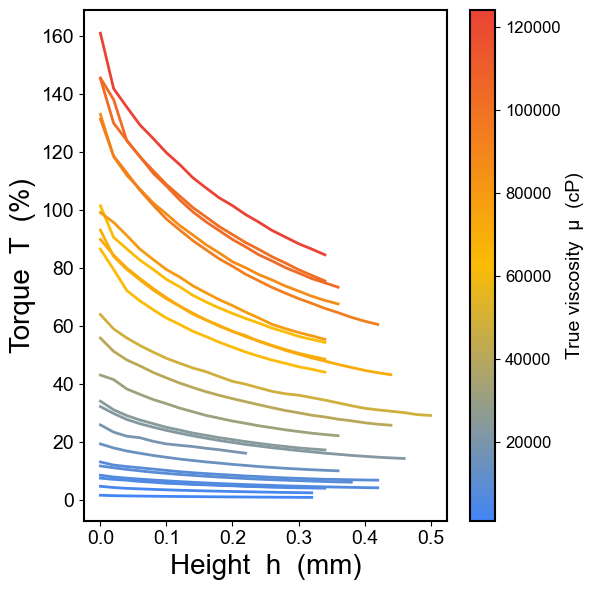

In [46]:
RE_COL = re.compile(
    r"^(?P<nom>[\d.]+)kcp_(?P<mu>[\d.]+)_torque_%_rpm_(?P<rpm>[\d.]+)$"
)

samples = []
for col in df_raw.columns:
    if col == "Height":
        continue
    m = RE_COL.match(col)
    if m:
        samples.append({
            "col": col,
            "nom_kcp": float(m["nom"]),
            "mu_cP": float(m["mu"]) * 1000.0,
            "rpm": float(m["rpm"]),
        })

df_meta = pd.DataFrame(samples).sort_values("mu_cP").reset_index(drop=True)
print(f"Parsed {len(df_meta)} silicone samples")
display(df_meta[["col", "nom_kcp", "mu_cP", "rpm"]])

# ── Raw torque vs. height — all samples overlaid ──────────────────────────────
h_raw = df_raw["Height"].values

norm_raw = plt.Normalize(vmin=df_meta["mu_cP"].min(), vmax=df_meta["mu_cP"].max())
sm_raw = plt.cm.ScalarMappable(cmap=GOOGLE_CMAP, norm=norm_raw)
sm_raw.set_array([])

fig, ax = plt.subplots(figsize=(6, 6))
for i, row in df_meta.iterrows():
    torque = df_raw[row["col"]].values
    ax.plot(h_raw, torque, color=GOOGLE_CMAP(norm_raw(row["mu_cP"])), lw=2.0)

ax.set_xlabel("Height  h  (mm)", fontsize=FS_LABEL)
ax.set_ylabel("Torque  T  (%)", fontsize=FS_LABEL)
_cb(sm_raw, ax, "True viscosity  μ  (cP)")
_gs(ax)
plt.tight_layout()
plt.show()


## Step 3 — Fit drag profiles D(h) = A/(h + h_c) + B for each sample

Drag-profile fits:


,nom_kcp,mu_cP,rpm,A,h_c,B,R2,n
0,1.0,1073.0,47.0,0.0060,0.2324,0.0062,0.9978,17
1,2.0,3345.0,15.0,0.0487,0.2066,0.0676,0.9978,17
2,5.0,5861.0,9.0,0.1813,0.2605,0.1332,0.9987,18
3,4.0,6603.0,8.0,0.2470,0.2769,0.1556,0.9996,22
4,8.0,8946.0,5.6,0.4849,0.2774,0.3335,0.9999,20
5,10.0,9152.0,5.5,0.4512,0.2482,0.5273,0.9982,22
6,12.5,14576.0,3.5,1.0384,0.2384,1.1023,0.9996,19
7,15.0,19036.0,2.6,0.8516,0.1457,3.9676,0.9927,12
8,25.0,22760.0,2.2,2.9377,0.2407,2.2525,0.9994,24
9,20.0,24396.0,2.1,2.5115,0.2015,3.5512,0.9990,18


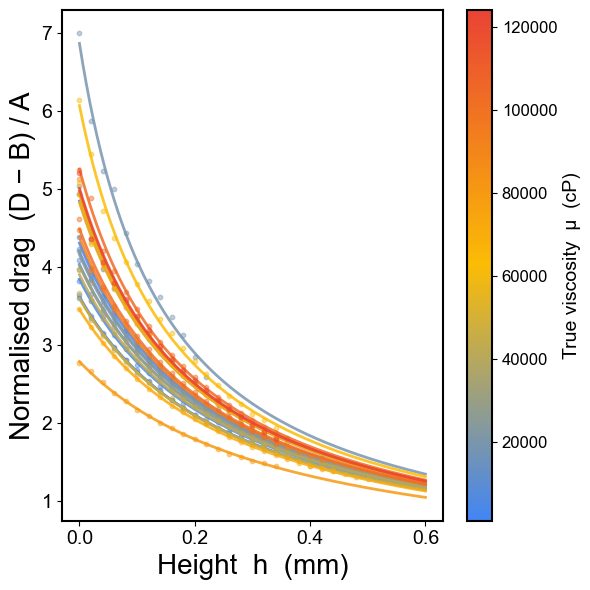

In [47]:
fit_rows = []

for _, row in df_meta.iterrows():
    h = h_raw - h_raw.min()
    T = df_raw[row["col"]].values
    D = T / row["rpm"]
    fit = fit_drag_profile(h, D, h_c=None)
    fit_rows.append({**row.to_dict(), **fit})

df_fits = pd.DataFrame(fit_rows)
print("Drag-profile fits:")
display(df_fits[["nom_kcp", "mu_cP", "rpm", "A", "h_c", "B", "R2", "n"]].round(4))

# ── Normalised drag curves + fits (all samples overlaid) ─────────────────────
h_plot = np.linspace(0, h_raw.max() - h_raw.min(), 200)
norm_fit = plt.Normalize(vmin=df_fits["mu_cP"].min(), vmax=df_fits["mu_cP"].max())
sm_fit = plt.cm.ScalarMappable(cmap=GOOGLE_CMAP, norm=norm_fit)
sm_fit.set_array([])

fig, ax = plt.subplots(figsize=(6, 6))
for _, row in df_fits.iterrows():
    h = h_raw - h_raw.min()
    D = df_raw[row["col"]].values / row["rpm"]
    D_norm = (D - row["B"]) / row["A"]
    D_fit_norm = 1.0 / (h_plot + row["h_c"])
    color = GOOGLE_CMAP(norm_fit(row["mu_cP"]))
    ax.scatter(h, D_norm, s=10, color=color, alpha=0.45, zorder=2)
    ax.plot(h_plot, D_fit_norm, color=color, lw=2.0, alpha=0.85)

ax.set_xlabel("Height  h  (mm)", fontsize=FS_LABEL)
ax.set_ylabel("Normalised drag  (D − B) / A", fontsize=FS_LABEL)
_cb(sm_fit, ax, "True viscosity  μ  (cP)")
_gs(ax)
plt.tight_layout()
plt.show()


## Step 4 — Load calibration & build A(μ) power-law model

=== Calibration Results ===
  h_c                      : 0.232399
  k                        : 5.75966e-09
  p                        : 1.9837
  R2_calibration           : 0.988727
  n_silicones              : 23


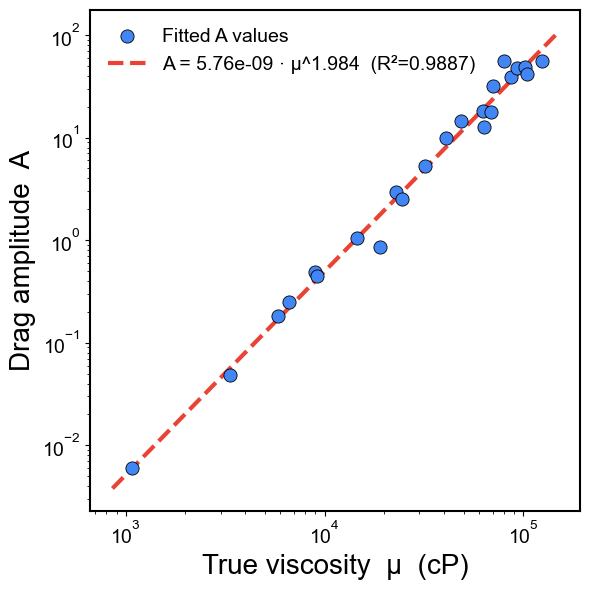


Universal h_c = 0.2324 mm
k = 5.7597e-09,  p = 1.9837


In [48]:
pipeline = RheologyPipeline()
cal = pipeline.load_silicone_calibration(CSV_PATH)

print("=== Calibration Results ===")
for k, v in cal.items():
    print(f"  {k:25s}: {v:.6g}")

good = df_fits[df_fits["R2"] > 0.7].copy()
mu_range = np.logspace(
    np.log10(good["mu_cP"].min() * 0.8),
    np.log10(good["mu_cP"].max() * 1.2), 200
)
A_fit_line = pipeline.SILICONE_K * mu_range ** pipeline.SILICONE_P

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(good["mu_cP"], good["A"],
           color=GOOGLE_COLORS[0], s=90, edgecolors="k",
           linewidths=0.6, zorder=3, label="Fitted A values")
ax.plot(mu_range, A_fit_line,
        color=GOOGLE_COLORS[1], lw=3, ls="--",
        label=(f"A = {pipeline.SILICONE_K:.2e} · μ^{pipeline.SILICONE_P:.3f}"
               f"  (R²={cal['R2_calibration']:.4f})"))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("True viscosity  μ  (cP)", fontsize=FS_LABEL)
ax.set_ylabel("Drag amplitude  A", fontsize=FS_LABEL)
ax.legend(fontsize=FS_LEGEND, frameon=False)
_gs(ax)
plt.tight_layout()
plt.show()

print(f"\nUniversal h_c = {pipeline.H_C_UNIVERSAL:.4f} mm")
print(f"k = {pipeline.SILICONE_K:.4e},  p = {pipeline.SILICONE_P:.4f}")


## Step 5 — Predict viscosity for every sample via the full pipeline

In [49]:
pred_rows = []

for _, row in df_meta.iterrows():
    h = h_raw - h_raw.min()
    T = df_raw[row["col"]].values

    result = pipeline.predict_rheology(h, T, row["rpm"])
    pred_rows.append({
        "nom_kcp"      : row["nom_kcp"],
        "true_mu_cP"   : row["mu_cP"],
        "rpm"          : row["rpm"],
        "pred_mu_cP"   : result.get("mu_app_cP", np.nan),
        "regime"       : result.get("regime", "?"),
        "fit_R2"       : result.get("fit_quality", np.nan),
        "A"            : result.get("A", np.nan),
    })

df_pred = pd.DataFrame(pred_rows)
df_pred["error_pct"] = (df_pred["pred_mu_cP"] - df_pred["true_mu_cP"]) / df_pred["true_mu_cP"] * 100

print("Predictions:")
display(df_pred.round(2))


Predictions:


,nom_kcp,true_mu_cP,rpm,pred_mu_cP,regime,fit_R2,A,error_pct
0,1.0,1073.0,47.0,1083.31,Newtonian,1.00,0.01,0.96
1,2.0,3345.0,15.0,3366.03,Newtonian,1.00,0.06,0.63
2,5.0,5861.0,9.0,5564.55,Newtonian,1.00,0.15,-5.06
3,4.0,6603.0,8.0,6262.50,Newtonian,1.00,0.20,-5.16
4,8.0,8946.0,5.6,8764.30,Newtonian,1.00,0.38,-2.03
5,10.0,9152.0,5.5,9133.85,Newtonian,1.00,0.41,-0.20
6,12.5,14576.0,3.5,14269.08,Newtonian,1.00,1.00,-2.11
7,15.0,19036.0,2.6,18357.14,Newtonian,0.99,1.65,-3.57
8,25.0,22760.0,2.2,23978.84,Newtonian,1.00,2.81,5.36
9,20.0,24396.0,2.1,24948.78,Newtonian,1.00,3.04,2.27


## Step 6 — Accuracy analysis & visualization

          ACCURACY REPORT
  Samples evaluated : 23
  MAPE              : 3.38%
  RMSE (log₁₀ cP)  : 0.0194
  Pearson r (log)   : 0.9995
  Within ±10%       : 95.7%
  Within ±20%       : 100.0%


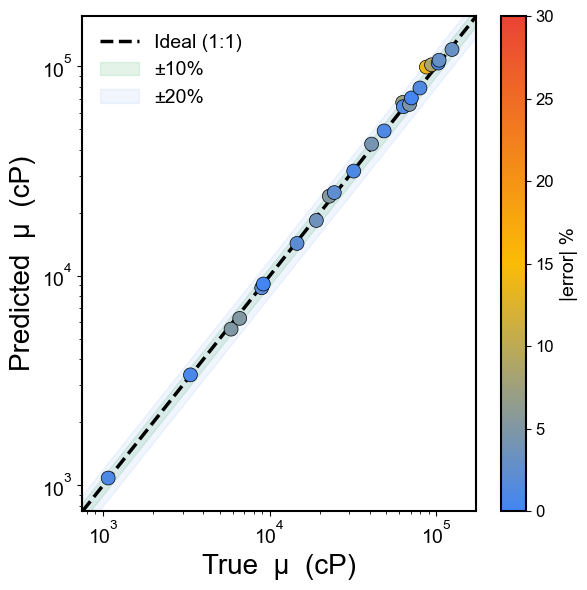

In [50]:
valid = df_pred.dropna(subset=["pred_mu_cP", "true_mu_cP"])

mae      = np.mean(np.abs(valid["error_pct"]))
mape     = mae
rmse_log = np.sqrt(np.mean((np.log10(valid["pred_mu_cP"]) - np.log10(valid["true_mu_cP"])) ** 2))
within10 = (np.abs(valid["error_pct"]) <= 10).mean() * 100
within20 = (np.abs(valid["error_pct"]) <= 20).mean() * 100

from scipy.stats import pearsonr
r, _ = pearsonr(np.log10(valid["true_mu_cP"]), np.log10(valid["pred_mu_cP"]))

print("=" * 45)
print("          ACCURACY REPORT")
print("=" * 45)
print(f"  Samples evaluated : {len(valid)}")
print(f"  MAPE              : {mape:.2f}%")
print(f"  RMSE (log₁₀ cP)  : {rmse_log:.4f}")
print(f"  Pearson r (log)   : {r:.4f}")
print(f"  Within ±10%       : {within10:.1f}%")
print(f"  Within ±20%       : {within20:.1f}%")
print("=" * 45)

# ── Figure 1: Parity plot (log-log) ──────────────────────────────────────────
lim = [valid["true_mu_cP"].min() * 0.7, valid["true_mu_cP"].max() * 1.4]

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(valid["true_mu_cP"], valid["pred_mu_cP"],
                c=valid["error_pct"].abs(), cmap=GOOGLE_CMAP,
                vmin=0, vmax=30, s=100,
                edgecolors="k", linewidths=0.5, zorder=3)
ax.plot(lim, lim, color="k", ls="--", lw=2.5, label="Ideal (1:1)")
ax.fill_between(lim, [v * 0.9 for v in lim], [v * 1.1 for v in lim],
                alpha=0.13, color=GOOGLE_COLORS[3], label="±10%")
ax.fill_between(lim, [v * 0.8 for v in lim], [v * 1.2 for v in lim],
                alpha=0.08, color=GOOGLE_COLORS[0], label="±20%")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("True  μ  (cP)", fontsize=FS_LABEL)
ax.set_ylabel("Predicted  μ  (cP)", fontsize=FS_LABEL)
ax.legend(fontsize=FS_LEGEND, frameon=False)
_cb(sc, ax, "|error| %")
_gs(ax)
plt.tight_layout()
plt.show()


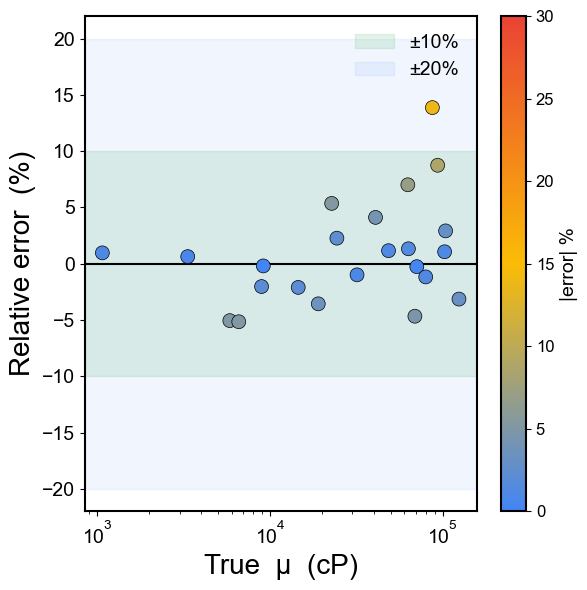

In [51]:
# ── Figure 2: % error vs. true viscosity ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.axhline(0, color="k", lw=1.5)
ax.axhspan(-10, 10, alpha=0.13, color=GOOGLE_COLORS[3], label="±10%")
ax.axhspan(-20, 20, alpha=0.08, color=GOOGLE_COLORS[0], label="±20%")
sc2 = ax.scatter(valid["true_mu_cP"], valid["error_pct"],
                 c=valid["error_pct"].abs(), cmap=GOOGLE_CMAP,
                 vmin=0, vmax=30, s=100,
                 edgecolors="k", linewidths=0.5, zorder=3)
ax.set_xscale("log")
ax.set_xlabel("True  μ  (cP)", fontsize=FS_LABEL)
ax.set_ylabel("Relative error  (%)", fontsize=FS_LABEL)
ax.legend(fontsize=FS_LEGEND, frameon=False)
_cb(sc2, ax, "|error| %")
_gs(ax)
plt.tight_layout()
plt.show()


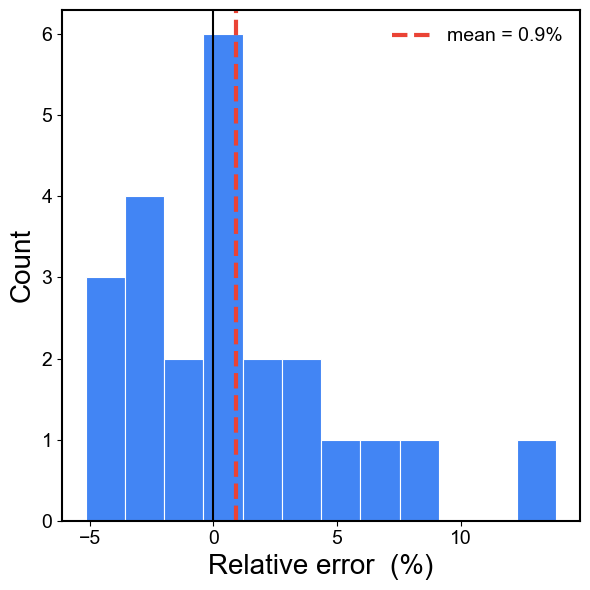

In [52]:
# ── Figure 3: Error histogram ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.hist(valid["error_pct"], bins=12,
        color=GOOGLE_COLORS[0], edgecolor="white", linewidth=0.8)
ax.axvline(0, color="k", lw=1.5)
ax.axvline(valid["error_pct"].mean(),
           color=GOOGLE_COLORS[1], lw=3, ls="--",
           label=f"mean = {valid['error_pct'].mean():.1f}%")
ax.set_xlabel("Relative error  (%)", fontsize=FS_LABEL)
ax.set_ylabel("Count", fontsize=FS_LABEL)
ax.legend(fontsize=FS_LEGEND, frameon=False)
_gs(ax)
plt.tight_layout()
plt.show()


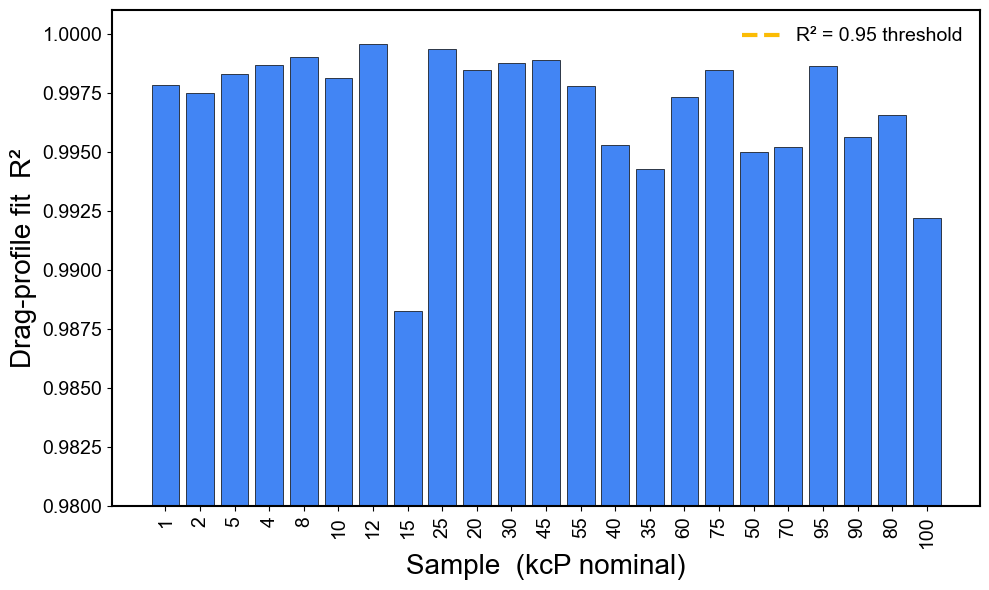

In [53]:
# ── Figure 4: Drag-profile fit quality (R² per sample) ───────────────────────
bar_colors = [GOOGLE_COLORS[1] if v < 0.95 else GOOGLE_COLORS[0]
              for v in valid["fit_R2"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(len(valid)), valid["fit_R2"].values,
       color=bar_colors, edgecolor="k", linewidth=0.5)
ax.axhline(0.95, color=GOOGLE_COLORS[2], lw=3, ls="--",
           label="R² = 0.95 threshold")
ax.set_xticks(range(len(valid)))
ax.set_xticklabels([f"{v:.0f}" for v in valid["nom_kcp"].values],
                   rotation=90, fontsize=FS_TICK)
ax.set_xlabel("Sample  (kcP nominal)", fontsize=FS_LABEL)
ax.set_ylabel("Drag-profile fit  R²", fontsize=FS_LABEL)
ax.set_ylim(0.98, 1.001)
ax.legend(fontsize=FS_LEGEND, frameon=False)
_gs(ax)
plt.tight_layout()
plt.show()


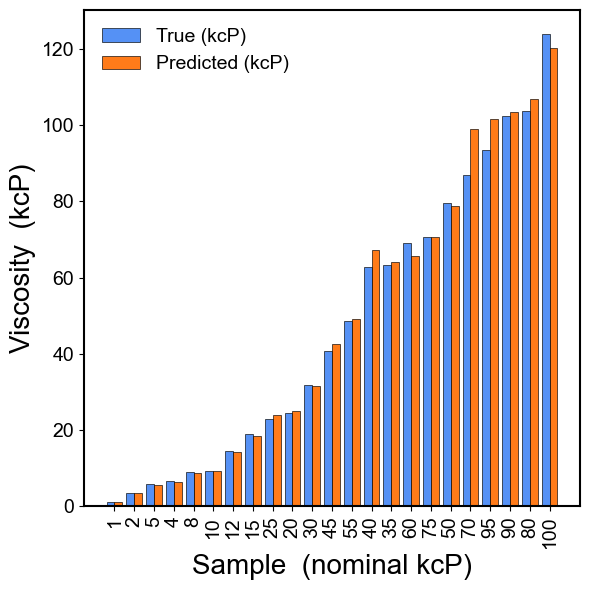

In [54]:
# ── Figure 5: True vs. predicted viscosity (grouped bar) ─────────────────────
x = np.arange(len(valid))
w = 0.4

fig, ax = plt.subplots(figsize=(6, 6))
ax.bar(x - w/2, valid["true_mu_cP"].values / 1000, w,
       label="True (kcP)", color=GOOGLE_COLORS[0], edgecolor="k",
       linewidth=0.5, alpha=0.9)
ax.bar(x + w/2, valid["pred_mu_cP"].values / 1000, w,
       label="Predicted (kcP)", color=GOOGLE_COLORS[4], edgecolor="k",
       linewidth=0.5, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([f"{v:.0f}" for v in valid["nom_kcp"].values],
                   rotation=90, fontsize=FS_TICK)
ax.set_xlabel("Sample  (nominal kcP)", fontsize=FS_LABEL)
ax.set_ylabel("Viscosity  (kcP)", fontsize=FS_LABEL)
ax.legend(fontsize=FS_LEGEND, frameon=False)
_gs(ax)
plt.tight_layout()
plt.show()


Saved: composite_analysis_figure.svg


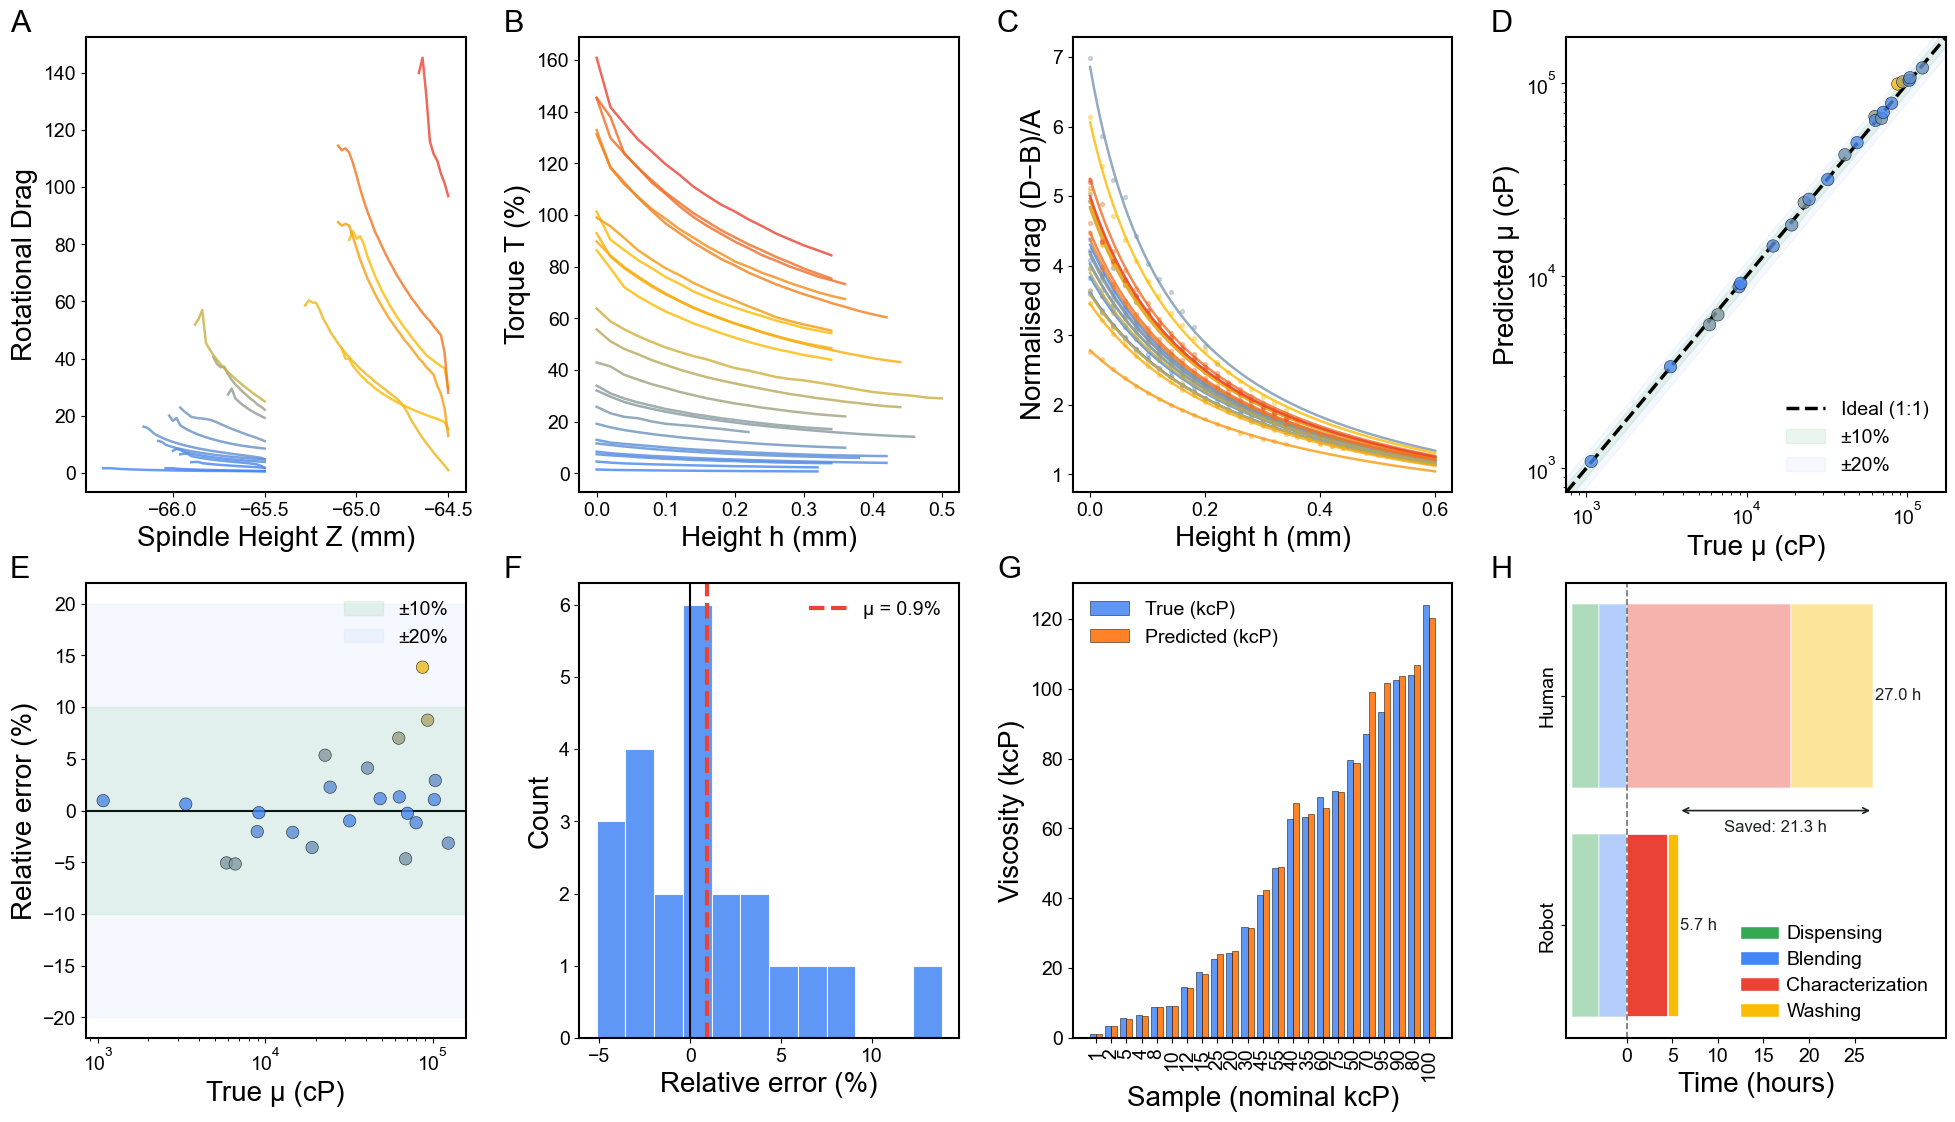

In [56]:

# ── Define Panel F: Robot vs Human timeline ──────────────────────────────────
def draw_panel_F(ax: plt.Axes) -> None:
    import matplotlib.patches as mpatches
    
    GOOGLE_BLUE   = "#4285F4"
    GOOGLE_GREEN  = "#34A853"
    GOOGLE_RED    = "#EA4335"
    GOOGLE_YELLOW = "#FBBC05"
    TICK_FS = 12
    LABEL_FS = 14
    LEGEND_FS = 12
    
    N_SAMPLES = 18
    operations = {
        "Blending\n(human)":         {"mins_per_sample": 10, "actor": "human", "color": GOOGLE_BLUE,   "human_only_mins_per_sample": 10},
        "Dispensing\n(human)":       {"mins_per_sample": 10, "actor": "human", "color": GOOGLE_GREEN,  "human_only_mins_per_sample": 10},
        "Characterization\n(robot)": {"mins_per_sample": 15, "actor": "robot", "color": GOOGLE_RED,    "human_only_mins_per_sample": 60},
        "Washing\n(robot)":          {"mins_per_sample":  4, "actor": "robot", "color": GOOGLE_YELLOW, "human_only_mins_per_sample": 30},
    }
    
    for cfg in operations.values():
        cfg["total_mins"] = cfg["mins_per_sample"] * N_SAMPLES
        cfg["total_human_only_mins"] = cfg["human_only_mins_per_sample"] * N_SAMPLES
        cfg["saved_mins"] = cfg["total_human_only_mins"] - cfg["total_mins"]
    
    plot_order = [1, 0, 2, 3]
    ordered_items = [list(operations.items())[i] for i in plot_order]
    colors_bar = [v["color"] for _, v in ordered_items]
    robot_vals_hr = [v["total_mins"] / 60.0 for _, v in ordered_items]
    human_vals_hr = [v["total_human_only_mins"] / 60.0 for _, v in ordered_items]
    
    a_lefts_h, a_lefts_r = [], []
    acc_h = acc_r = 0.0
    for hv, rv in zip(human_vals_hr, robot_vals_hr):
        a_lefts_h.append(acc_h)
        a_lefts_r.append(acc_r)
        acc_h += hv
        acc_r += rv
    
    dispensing_end_hr = human_vals_hr[0] + human_vals_hr[1]
    lefts_h = [x - dispensing_end_hr for x in a_lefts_h]
    lefts_r = [x - dispensing_end_hr for x in a_lefts_r]
    
    total_human_only_rel = sum(human_vals_hr) - dispensing_end_hr
    total_activity_rel = sum(robot_vals_hr) - dispensing_end_hr
    focus_saved_hr = sum(human_vals_hr[2:]) - sum(robot_vals_hr[2:])
    
    for idx, (c, hv, rv, lh, lr) in enumerate(zip(colors_bar, human_vals_hr, robot_vals_hr, lefts_h, lefts_r)):
        ax.barh(1, hv, left=lh, color=c, alpha=0.4, edgecolor="white", linewidth=1.2)
        alpha_robot = 0.4 if idx < 2 else 1.0
        ax.barh(0, rv, left=lr, color=c, alpha=alpha_robot, edgecolor="white", linewidth=1.2)
    
    ax.text(total_human_only_rel + 0.18, 1, f"{total_human_only_rel:.1f} h", va="center", ha="left", fontsize=TICK_FS, color="#202124")
    ax.text(total_activity_rel + 0.18, 0, f"{total_activity_rel:.1f} h", va="center", ha="left", fontsize=TICK_FS, color="#202124")
    
    ax.axvline(0, color="#5F6368", linestyle="--", linewidth=1.2, alpha=0.9)
    mid_y = 0.5
    ax.annotate(
        "", xy=(total_activity_rel, mid_y), xytext=(total_human_only_rel, mid_y),
        arrowprops=dict(arrowstyle="<->", color="#202124", lw=1.2),
    )
    
    ax.text(
        (total_activity_rel + total_human_only_rel) / 2, mid_y - 0.04,
        f"Saved: {focus_saved_hr:.1f} h",
        ha="center", va="top", color="#202124", fontsize=TICK_FS,
    )
    
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Robot", "Human"], color="black", fontsize=30, rotation=90, va="center")
    ax.set_xlabel("Time (hours)", fontsize=FS_LABEL)
    ax.set_xlim(-(dispensing_end_hr + 0.6), 35)
    xticks = np.arange(0, total_human_only_rel + 2.0, 5.0)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{x:g}" for x in xticks], fontsize=TICK_FS)
    
    legend_labels = ["Dispensing", "Blending", "Characterization", "Washing"]
    legend_colors = [GOOGLE_GREEN, GOOGLE_BLUE, GOOGLE_RED, GOOGLE_YELLOW]
    legend_handles = [
        mpatches.Patch(facecolor=c, edgecolor="white", linewidth=1.0, label=l)
        for l, c in zip(legend_labels, legend_colors)
    ]
    ax.legend(handles=legend_handles, loc="lower right", ncol=1, fontsize=LEGEND_FS + 2, frameon=False, handletextpad=0.4, labelspacing=0.4)
    _gs(ax)


# ── Composite Figure: All subplots in a 2x4 grid ──────────────────────────────
fig = plt.figure(figsize=(24, 13))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.20, wspace=0.30)

axes = [
    fig.add_subplot(gs[0, 0]),  # A
    fig.add_subplot(gs[0, 1]),  # B
    fig.add_subplot(gs[0, 2]),  # C
    fig.add_subplot(gs[0, 3]),  # D
    fig.add_subplot(gs[1, 0]),  # E
    fig.add_subplot(gs[1, 1]),  # F
    fig.add_subplot(gs[1, 2]),  # G
    fig.add_subplot(gs[1, 3]),  # H
]

# ── A: Drag vs Z-Height ──────────────────────────────────────────────────────
ax = axes[0]
for label in labels_ordered:
    kcp = _kcp(label)
    sub = df_run[df_run["Cell_Label"] == label].sort_values("Z_Height_mm")
    ax.plot(sub["Z_Height_mm"], sub["Rotational_Drag"],
            color=GOOGLE_CMAP(norm_run(kcp)), lw=1.8, alpha=0.8)
ax.set_xlabel("Spindle Height Z (mm)", fontsize=FS_LABEL)
ax.set_ylabel("Rotational Drag", fontsize=FS_LABEL)
_gs(ax)
ax.text(-0.2, 1.06, 'A', transform=ax.transAxes, fontsize=22, fontweight='normal', va='top')

# ── B: Raw torque vs. height ─────────────────────────────────────────────────
ax = axes[1]
h_raw = df_raw["Height"].values
for i, row in df_meta.iterrows():
    torque = df_raw[row["col"]].values
    ax.plot(h_raw, torque, color=GOOGLE_CMAP(norm_raw(row["mu_cP"])), lw=1.8, alpha=0.8)
ax.set_xlabel("Height h (mm)", fontsize=FS_LABEL)
ax.set_ylabel("Torque T (%)", fontsize=FS_LABEL)
_gs(ax)
ax.text(-0.2, 1.06, 'B', transform=ax.transAxes, fontsize=22, fontweight='normal', va='top')

# ── C: Normalised drag curves + fits ──────────────────────────────────────────
ax = axes[2]
h_plot = np.linspace(0, h_raw.max() - h_raw.min(), 200)
for _, row in df_fits.iterrows():
    h = h_raw - h_raw.min()
    D = df_raw[row["col"]].values / row["rpm"]
    D_norm = (D - row["B"]) / row["A"]
    D_fit_norm = 1.0 / (h_plot + row["h_c"])
    color = GOOGLE_CMAP(norm_fit(row["mu_cP"]))
    ax.scatter(h, D_norm, s=8, color=color, alpha=0.35, zorder=2)
    ax.plot(h_plot, D_fit_norm, color=color, lw=1.8, alpha=0.8, zorder=2)
ax.set_xlabel("Height h (mm)", fontsize=FS_LABEL)
ax.set_ylabel("Normalised drag (D−B)/A", fontsize=FS_LABEL)
_gs(ax)
ax.text(-0.2, 1.06, 'C', transform=ax.transAxes, fontsize=22, fontweight='normal', va='top')

# ── D: Parity plot (log-log) ─────────────────────────────────────────────────
ax = axes[3]
lim = [valid["true_mu_cP"].min() * 0.7, valid["true_mu_cP"].max() * 1.4]
ax.scatter(valid["true_mu_cP"], valid["pred_mu_cP"],
           c=valid["error_pct"].abs(), cmap=GOOGLE_CMAP,
           vmin=0, vmax=30, s=80, edgecolors="k", linewidths=0.4, zorder=3, alpha=0.8)
ax.plot(lim, lim, color="k", ls="--", lw=2.5, label="Ideal (1:1)")
ax.fill_between(lim, [v * 0.9 for v in lim], [v * 1.1 for v in lim],
                alpha=0.10, color=GOOGLE_COLORS[3], label="±10%")
ax.fill_between(lim, [v * 0.8 for v in lim], [v * 1.2 for v in lim],
                alpha=0.05, color=GOOGLE_COLORS[0], label="±20%")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("True μ (cP)", fontsize=FS_LABEL)
ax.set_ylabel("Predicted μ (cP)", fontsize=FS_LABEL)
ax.legend(fontsize=FS_LEGEND, frameon=False, loc='lower right')
_gs(ax)
ax.text(-0.2, 1.06, 'D', transform=ax.transAxes, fontsize=22, fontweight='normal', va='top')

# ── E: % error vs. true viscosity ────────────────────────────────────────────
ax = axes[4]
ax.axhline(0, color="k", lw=1.5, zorder=1)
ax.axhspan(-10, 10, alpha=0.10, color=GOOGLE_COLORS[3], label="±10%")
ax.axhspan(-20, 20, alpha=0.05, color=GOOGLE_COLORS[0], label="±20%")
ax.scatter(valid["true_mu_cP"], valid["error_pct"],
           c=valid["error_pct"].abs(), cmap=GOOGLE_CMAP,
           vmin=0, vmax=30, s=80, edgecolors="k", linewidths=0.4, zorder=3, alpha=0.8)
ax.set_xscale("log")
ax.set_xlabel("True μ (cP)", fontsize=FS_LABEL)
ax.set_ylabel("Relative error (%)", fontsize=FS_LABEL)
ax.legend(fontsize=FS_LEGEND, frameon=False, loc='upper right')
_gs(ax)
ax.text(-0.2, 1.06, 'E', transform=ax.transAxes, fontsize=22, fontweight='normal', va='top')

# ── F: Error histogram ───────────────────────────────────────────────────────
ax = axes[5]
ax.hist(valid["error_pct"], bins=12,
        color=GOOGLE_COLORS[0], edgecolor="white", linewidth=0.8, alpha=0.85)
ax.axvline(0, color="k", lw=1.5, zorder=2)
ax.axvline(valid["error_pct"].mean(),
           color=GOOGLE_COLORS[1], lw=3, ls="--", zorder=2,
           label=f"μ = {valid['error_pct'].mean():.1f}%")
ax.set_xlabel("Relative error (%)", fontsize=FS_LABEL)
ax.set_ylabel("Count", fontsize=FS_LABEL)
ax.legend(fontsize=FS_LEGEND, frameon=False)
_gs(ax)
ax.text(-0.2, 1.06, 'F', transform=ax.transAxes, fontsize=22, fontweight='normal', va='top')

# ── G: True vs. predicted viscosity (grouped bar) ────────────────────────────
ax = axes[6]
x = np.arange(len(valid))
w = 0.4
ax.bar(x - w/2, valid["true_mu_cP"].values / 1000, w,
       label="True (kcP)", color=GOOGLE_COLORS[0], edgecolor="k",
       linewidth=0.4, alpha=0.85, zorder=2)
ax.bar(x + w/2, valid["pred_mu_cP"].values / 1000, w,
       label="Predicted (kcP)", color=GOOGLE_COLORS[4], edgecolor="k",
       linewidth=0.4, alpha=0.85, zorder=2)
ax.set_xticks(x)
ax.set_xticklabels([f"{v:.0f}" for v in valid["nom_kcp"].values],
                   rotation=90, fontsize=10)
ax.set_xlabel("Sample (nominal kcP)", fontsize=FS_LABEL)
ax.set_ylabel("Viscosity (kcP)", fontsize=FS_LABEL)
ax.legend(fontsize=FS_LEGEND, frameon=False)
_gs(ax)
ax.text(-0.2, 1.06, 'G', transform=ax.transAxes, fontsize=22, fontweight='normal', va='top')

# ── H: Robot vs Human timeline ───────────────────────────────────────────────
ax = axes[7]
draw_panel_F(ax)
ax.text(-0.2, 1.06, 'H', transform=ax.transAxes, fontsize=22, fontweight='normal', va='top')

# Save as SVG
output_svg = REPO / "composite_analysis_figure.svg"
plt.savefig(output_svg, format="svg", bbox_inches="tight", dpi=300)
print(f"Saved: {output_svg.name}")

plt.show()
